# Part 2 Model Building Assignment

Submitters: Kfir Ziso and Yael Bukris

ID: 322883091,324050178

GitHub: https://github.com/KfirZiso/movie-rating-prediction

<center>
    <img src="https://www.panoramaaudiovisual.com/wp-content/uploads/2019/06/IMDB.jpg" width="700" style="display: inline-block;">
</center>

## Library and Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import ast
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict, RandomizedSearchCV, cross_validate
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
path = 'dataset.csv'
df = pd.read_csv(path, na_values=['\\N', '\\\\N'])
df.head()

C:\Users\kfirz\AppData\Local\Temp\ipykernel_38440\3627196558.py:2: DtypeWarning: Columns (0: budget) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, na_values=['\\N', '\\\\N'])


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


## Finding the Top 300 Actors

In [3]:
df_fixed = df.dropna(subset=['averageRating']).reset_index(drop=True)

df_fixed['budget'] = pd.to_numeric(df_fixed['budget'], errors='coerce')

top_expensive = df_fixed.nlargest(1500, 'budget')
all_actors = top_expensive['lead_actors_ids'].dropna().astype(str).str.split(',').explode().str.strip()
my_top_actors_list = all_actors.value_counts().head(300).index.tolist()

print("🎯 Top 300 actors list extracted successfully and printed here:")
print(my_top_actors_list)

🎯 Top 300 actors list extracted successfully and printed here:
['[]', "'nm0262635'", "['nm0000136'", "['nm0001815'", "'nm0001485'", '"nm0005351"', "'nm0000172'", 'nm0695435', "['nm0000044'", "'nm0001001'", '["nm0000151"', "['nm0000034'", "['nm0000134'", '"nm0476223"', "['nm0000078'", "['nm0000331'", "['nm0001088'", "'nm0413168'", "'nm0914113'", '["nm0265492"', '["nm0005351"', "'nm0001522'", '"nm0000982"', '["nm0136797"', '"nm0000168"', "'nm0000336'", '"nm0000460"', '["nm0222426"', '"nm0005048"', "'nm0000679'", "['nm0000125'", "'nm0001599'", "['nm0000158'", "'nm0000104'", '"nm0001626"', "'nm0000587'", '"nm0034519"', "'nm0491590']", "['nm0000056'", "'nm0001424'", "'nm0000177'", '["nm0394690"', '"nm0001136"', '["nm0000241"', "['nm0000288'", '"nm0613147"', "['nm0000142'", "'nm0428086'", '"nm0000609"', "'nm0334689'", "'nm0000987'", "'nm0000897'", "'nm0001691'", "'nm0000350'", '"nm0667664"', '["nm0001958"', '"nm1347153"', "['nm0000011'", '"nm0682074"', '["nm0000060"', "['nm0001522'", "['nm00

## Prepare Data

In [4]:
def prepare_data(df):
    X = df.copy()
    if 'runtimeMinutes' in X.columns:
        X['runtimeMinutes'] = pd.to_numeric(X['runtimeMinutes'], errors='coerce')

    if 'startYear' in X.columns:
        X['startYear'] = pd.to_numeric(X['startYear'], errors='coerce')
        invalid_years_mask = (X['startYear'].notna()) & ((X['startYear'] < 1000) | (X['startYear'] > 9999))
        X.loc[invalid_years_mask, 'startYear'] = np.nan
        X['startYear'] = X['startYear'].astype('Int64')

    if 'genres' in X.columns:
        X['genres'] = X['genres'].dropna().astype(str)
        X['genres'] = X['genres'].str.replace(r"[\[\]\'\"]", "", regex=True)
        X['genres'] = X['genres'].apply(lambda x: '' if x in ['\\N', 'N', '\\\\N'] else x)

    if 'lead_actors_ids' in X.columns:
        X['lead_actors_ids'] = X['lead_actors_ids'].fillna('').astype(str)
        X['lead_actors_ids'] = X['lead_actors_ids'].replace(['\\N', '\\\\N', 'N', 'nan', 'None'], '')
        X['lead_actors_ids'] = X['lead_actors_ids'].str.replace(r"[\[\]\'\"]", "", regex=True)

    valid_countries_list = [
        'USA', 'United States', 'UK', 'United Kingdom', 'Canada', 'France', 'Germany', 'Italy',
        'Spain', 'Japan', 'China', 'India', 'South Korea', 'Australia', 'Israel', 'Argentina',
        'Brazil', 'Mexico', 'Netherlands', 'Sweden', 'Switzerland', 'Russia', 'Turkey', 'Belgium'
    ]
    valid_languages_list = [
        'English', 'Hebrew', 'Arabic', 'French', 'Spanish', 'German', 'Italian', 'Japanese',
        'Mandarin', 'Cantonese', 'Chinese', 'Korean', 'Russian', 'Hindi', 'Tamil', 'Telugu',
        'Portuguese', 'Dutch', 'Swedish', 'Turkish'
    ]

    def clean_scraped_text_to_nan(val, valid_list):
        if pd.isna(val) or val in ['\\N', '\\\\N', 'N', 'nan', 'None', '']:
            return None
        val_str = str(val)
        found_items = []
        for item in valid_list:
            if item.lower() in val_str.lower():
                if item in ['United States', 'USA']: found_items.append('USA')
                elif item in ['United Kingdom', 'UK']: found_items.append('UK')
                else: found_items.append(item)
        found_items = list(set(found_items))
        return ", ".join(found_items) if found_items else None

    if 'Country' in X.columns:
        X['Country'] = X['Country'].apply(lambda x: clean_scraped_text_to_nan(x, valid_countries_list))
    if 'Language' in X.columns:
        X['Language'] = X['Language'].apply(lambda x: clean_scraped_text_to_nan(x, valid_languages_list))

    if 'averageRating' in X.columns:
        X = X.dropna(subset=['averageRating'])

    X = X.reset_index(drop=True)

    leakage_columns = ['numVotes', 'BoxOffice']
    X = X.drop(columns=[col for col in leakage_columns if col in X.columns], errors='ignore')

    if 'averageRating' in X.columns:
        X = X.drop(columns=['averageRating'])

    if 'genres' in X.columns: X['genres'] = X['genres'].fillna('')
    if 'lead_actors_ids' in X.columns: X['lead_actors_ids'] = X['lead_actors_ids'].fillna('')
    if 'Language' in X.columns: X['Language'] = X['Language'].fillna('')
    if 'Country' in X.columns: X['Country'] = X['Country'].fillna('')

    if 'genres' in X.columns:
        X['genre_count'] = X['genres'].apply(lambda x: len([g for g in str(x).split(',') if g.strip()]) if str(x).strip() else 0)
    else:
        X['genre_count'] = 0

    if 'startYear' in X.columns:
        X['is_post_imdb'] = (X['startYear'] >= 1991).fillna(False).astype(int)
    else:
        X['is_post_imdb'] = 0

    if 'lead_actors_ids' in X.columns:
        current_top_actors = set(['[]', "'nm0262635'", "'nm0001485'", "['nm0001815'", "['nm0000136'", '"nm0005351"', 'nm0695435', "'nm0000172'", "['nm0000078'", "['nm0000034'", '["nm0000151"', "'nm0001001'", "['nm0000331'", "'nm0413168'", "['nm0001088'", "['nm0000044'", "['nm0000134'", '"nm0476223"', "['nm0000011'", '"nm0000168"', "['nm0001076'", '["nm0394690"', "'nm0000336'", 'nm0342488', "'nm0001522'", 'nm0914612', "'nm0039989'", "['nm0000158'", "'nm0472603'", "'nm0000177'", '["nm0005351"', "'nm0334689'", "'nm0001599'", "['nm0000125'", "'nm0001424'", "'nm0000679'", "['nm0001635'", 'nm0705356', "['nm0001766'", "['nm0001522'", '"nm0000609"', '["nm0000060"', '"nm1347153"', '"nm0034519"', '"nm0001136"', "'nm0491590']", "['nm0000056'", '["nm0136797"', '"nm0682074"', '"nm0000982"', "'nm0001691'", '"nm0001626"', '["nm0000241"', "'nm0000104'", "'nm0001958'", "['nm0000064'", '["nm0001958"', "'nm0000587'", '["nm0265492"', "'nm0000897'", "['nm0000288'", "['nm0000375'", '"nm0667664"', "'nm0000350'", "'nm0749263']", '["nm0001224"', "'nm0000992']", '["nm0222426"', "'nm0914113'", '"nm0613147"', '"nm0005048"', '["nm0000859"', "['nm0001791'", "'nm0000023'", "['nm0000142'", '"nm0000460"', "'nm0428086'", "'nm0000987'", "'nm0654239'", '"nm1043075"', '["nm0000120"', "'nm0000380'", '"nm0101350"', '"nm0005541"', "'nm0000947'", "'nm0927240'", "'nm0090123'", "['nm0001224'", "'nm0662223'", '"nm0129894"', "['nm0001772'", "['nm0000126'", '"nm0505249"', "'nm0877270']", '"nm0000973"', '"nm0001872"', '"nm0001570"', '"nm1258970"', '["nm0000245"', '"nm0000634"', '"nm1443527"', '"nm1706767"', "'nm0000661'", "['nm0198072'", "'nm1399741'", '["nm0001774"', '"nm0669681"', '"nm0628091"', "'nm0182839'", '"nm0827663"', "'nm0721073'", "['nm0000432'", "'nm0001174'", '"nm0451307"', "['nm0000276'", "'nm0041281'", "['nm0000702'", '"nm0001557"', 'nm0002091', '["nm0000858"', 'nm0177896', "'nm0570615']", "['nm1940449'", "'nm0875861'", '"nm0912001"', "'nm14476135'", '["nm0005327"', "'nm1297015'", "'nm0005196'", "['nm0000947'", "'nm0233352'", "'nm0837959'", '"nm0446672"]', "'nm0108406'", "'nm0000554'", '["nm0002071"', '"nm0000242"', "['nm0000401'", "'nm0002332'", "['nm0912487'", "['nm0000219'", '["nm0000598"', '"nm0316079"', "'nm0206478'", "'nm1716941'", "'nm0169806']", '["nm0654110"', "'nm0005162']", '"nm0225419"', "'nm0388872'", "'nm0173735'", "'nm0001695'", "['nm1431656'", "['nm0041405'", "'nm0000173'", "'nm0001520'", "'nm0132257'", '"nm0534317"', "'nm0000271'", "['nm0001428'", "'nm0001800'", '"nm0000174"', "'nm0000730'", "'nm0000079'", "'nm0007220'", 'nm0004874', 'nm0757855', 'nm1176985', "'nm0000308'", "['nm0634159'", "'nm0448765'", '["nm0124930"', "'nm0218131'", "'nm0001028'", '"nm0507212"', '["nm0000140"', "['nm0004496'", "['nm0318105'", "'nm0000840'", "'nm0943978'", '"nm0958335"', "'nm0001624']", "'nm1343961'", "'nm0000932'", "['nm0000621'", "['nm0425005'", "['nm0000102'", "'nm0187981'", "'nm0799777'", "'nm0843401'", '"nm0048414"', "'nm0803785'", "'nm1431940'", '["nm0000336"', '"nm0004496"', '"nm0525601"', '"nm0671738"]', "'nm0000210'", "'nm0910278'", "['nm0228715'", '"nm0001434"', "['nm0400998'", "['nm0438463'", "'nm0004866'", "'nm0269647'", "['nm0706368'", "'nm0001656'", "'nm0000039'", '"nm0860233"', '"nm0227759"', '"nm0007234"', '["nm0000177"', '"nm0000177"', "'nm0415591'", '"nm0403134"', "'nm0867694'", "'nm0000763'", '"nm1683094"', "'nm2225369'", "['nm0428065'", "'nm0480465'", "['nm5397459'", "'nm3915784'", "'nm1209966'", '"nm0001800"', "'nm0666604'", "'nm0611898'", '["nm0947447"', "'nm0000748']", "'nm0832011'", "'nm0440514'", "'nm4928333'", '"nm0000547"', '"nm0306786"', "['nm0000140'", "'nm0000375'", '"nm0001993"', "['nm0001062'", '"nm0623762"', '"nm0202966"', '"nm0397928"', "'nm0019996'", "'nm0179154'", '"nm0112043"', "'nm0001884'", '["nm0000152"', "'nm0000244'", "'nm0757855'", "['nm0941777'", '"nm0045741"', "'nm10771694'", "['nm0000009'", "['nm0322513'", "'nm0000744'", "'nm0000959'", "['nm0000560'", "'nm0000130'", '"nm2812744"', "'nm0000286'", "'nm0407959'", "'nm0000704'", "'nm0483653']", "'nm0000518'", "'nm0166706'", "'nm0369814'", "'nm0268225'", '"nm0000336"', "'nm0000169'", '"nm0698764"', '["nm0000277"', '["nm0001791"', '["nm0000199"', "'nm0000099'", '"nm0433150"', '"nm0557339"', "'nm0574534'", "'nm0005212'", '"nm0000502"', "'nm6533985'", "'nm0006893'", "'nm0735442'", "'nm0000149'", "'nm0140865'", '"nm0870543"', "['nm0682074'", "'nm0001191'", "['nm0185819'", "'nm0254975'", "['nm0000297'", "'nm0000204'", "['nm1165110'", "'nm0380965'", "'nm0587534']", "'nm0001701'", '"nm0001520"]', "'nm0000496'", '"nm0001283"', "['nm0000424'", "'nm0000114'", "'nm0436642'"]) # תדביקי פה את כל הרשימה שהודפסה

        def count_a_listers(actors_str):
            if str(actors_str).strip() == '':
                return 0
            movie_actors = [a.strip() for a in str(actors_str).split(',')]
            return sum(1 for a in movie_actors if a in current_top_actors)

        X['num_a_list_actors'] = X['lead_actors_ids'].apply(count_a_listers)
    else:
        X['num_a_list_actors'] = 0


    if 'Language' in X.columns:
        X['is_english'] = X['Language'].apply(lambda x: 1 if 'English' in str(x) else 0)
    else:
        X['is_english'] = 0

    if 'Country' in X.columns:
        X['is_usa'] = X['Country'].apply(lambda x: 1 if 'USA' in str(x) or 'United States' in str(x) else 0)
    else:
        X['is_usa'] = 0

    if 'runtimeMinutes' in X.columns:
        X['runtime_category_num'] = pd.cut(
            X['runtimeMinutes'],
            bins=[0, 85, 130, 1000],
            labels=[1, 2, 3],
            ordered=True
        ).astype(float)
    else:
        X['runtime_category_num'] = np.nan

    top_genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Romance', 'Sci-Fi', 'Horror', 'Documentary']
    for genre in top_genres:
        if 'genres' in X.columns:
            X[f'genre_{genre}'] = X['genres'].apply(lambda x: 1 if genre in str(x) else 0)
        else:
            X[f'genre_{genre}'] = 0

    cols_to_drop = [
        'tconst', 'primaryTitle', 'plot',
        'startYear', 'genres', 'lead_actors_ids',
        'Language', 'Country', 'budget'
    ]
    X = X.drop(columns=[col for col in cols_to_drop if col in X.columns], errors='ignore')

    return X

In [5]:
X_prepare_data=prepare_data(df)
X_prepare_data.head()

,runtimeMinutes,genre_count,is_post_imdb,num_a_list_actors,is_english,is_usa,runtime_category_num,genre_Action,genre_Comedy,genre_Drama,genre_Thriller,genre_Romance,genre_Sci-Fi,genre_Horror,genre_Documentary
0,90.0,3,1,0,0,0,2.0,0,0,1,1,0,0,0,0
1,86.0,1,1,0,0,0,2.0,0,0,1,0,0,0,0,0
2,102.0,1,1,0,0,0,2.0,0,1,0,0,0,0,0,0
3,85.0,3,1,0,0,0,1.0,0,0,0,0,0,0,0,1
4,170.0,1,1,0,0,0,3.0,0,0,0,0,0,0,0,1


## Model Building

In [6]:
warnings.filterwarnings('ignore')

df_fixed = df.dropna(subset=['averageRating']).reset_index(drop=True)
y = df_fixed['averageRating']

X_raw = prepare_data(df_fixed)

numeric_features = X_raw.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object', 'string']).columns.tolist()

for col in categorical_features:
    X_raw[col] = X_raw[col].astype(object)

def convert_to_string(X):
    return X.astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('stringify', FunctionTransformer(convert_to_string)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

scoring_metrics = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

numeric_transformer_elastic = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_elastic = ColumnTransformer(transformers=[
    ('num', numeric_transformer_elastic, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

elastic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_elastic),
    ('model', ElasticNet(random_state=42, max_iter=5000, tol=0.0001))
])

param_grid_elastic = {
    'model__alpha': [0.001, 0.01, 0.05, 0.1, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_elastic = GridSearchCV(
    estimator=elastic_pipeline, param_grid=param_grid_elastic,
    cv=10, scoring=scoring_metrics, refit='rmse', n_jobs=-1
)

print("⏳ Running 10-Fold CV and calculating metrics for Elastic Net...")
grid_elastic.fit(X_raw, y)

best_idx_elastic = grid_elastic.best_index_
results_elastic = grid_elastic.cv_results_

print(f"\n✅ ======= 10-Fold CV Results: Elastic Net ======= ✅")
print(f"Selected Parameters: Alpha={grid_elastic.best_params_['model__alpha']}, L1_Ratio={grid_elastic.best_params_['model__l1_ratio']}")
print(f"RMSE: {-results_elastic['mean_test_rmse'][best_idx_elastic]:.4f} (± {results_elastic['std_test_rmse'][best_idx_elastic]:.4f})")
print(f"MAE:  {-results_elastic['mean_test_mae'][best_idx_elastic]:.4f} (± {results_elastic['std_test_mae'][best_idx_elastic]:.4f})")
print(f"R²:   {results_elastic['mean_test_r2'][best_idx_elastic]:.4f} (± {results_elastic['std_test_r2'][best_idx_elastic]:.4f})")
print("==================================================\n")

numeric_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor_rf = ColumnTransformer(transformers=[
    ('num', numeric_transformer_rf, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(n_estimators=100, max_features=0.7, random_state=42))
])

param_grid_rf = {
    'model__max_depth': [10, 15],
    'model__min_samples_leaf': [2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline, param_grid=param_grid_rf,
    cv=10, scoring=scoring_metrics, refit='rmse', n_jobs=-1
)

print("⏳ Running 10-Fold CV and calculating metrics for Random Forest...")
grid_rf.fit(X_raw, y)

best_idx_rf = grid_rf.best_index_
results_rf = grid_rf.cv_results_

print(f"\n✅ ======= 10-Fold CV Results: Random Forest ======= ✅")
print(f"Selected Parameters: max_depth={grid_rf.best_params_['model__max_depth']}, min_samples_leaf={grid_rf.best_params_['model__min_samples_leaf']}")
print(f"RMSE: {-results_rf['mean_test_rmse'][best_idx_rf]:.4f} (± {results_rf['std_test_rmse'][best_idx_rf]:.4f})")
print(f"MAE:  {-results_rf['mean_test_mae'][best_idx_rf]:.4f} (± {results_rf['std_test_mae'][best_idx_rf]:.4f})")
print(f"R²:   {results_rf['mean_test_r2'][best_idx_rf]:.4f} (± {results_rf['std_test_r2'][best_idx_rf]:.4f})")
print("==================================================")


⏳ Running 10-Fold CV and calculating metrics for Elastic Net...

✅ ======= 10-Fold CV Results: Elastic Net ======= ✅
Selected Parameters: Alpha=0.001, L1_Ratio=0.3
RMSE: 1.1267 (± 0.0486)
MAE:  0.8636 (± 0.0357)
R²:   0.2368 (± 0.0223)

⏳ Running 10-Fold CV and calculating metrics for Random Forest...

✅ ======= 10-Fold CV Results: Random Forest ======= ✅
Selected Parameters: max_depth=10, min_samples_leaf=4
RMSE: 1.1205 (± 0.0493)
MAE:  0.8579 (± 0.0368)
R²:   0.2452 (± 0.0233)


## Error Analysis

In [7]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

final_pipeline_for_cv = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1))
])

print("Calculating predictions for all movies (this may take about a minute)...")
y_cv_preds = cross_val_predict(final_pipeline_for_cv, X_raw, y, cv=kf, n_jobs=-1)

analysis_df = df_fixed.copy()
analysis_df['Predicted_Rating'] = y_cv_preds
analysis_df['Error'] = analysis_df['Predicted_Rating'] - analysis_df['averageRating']

over_preds = analysis_df.nlargest(10, 'Error')
under_preds = analysis_df.nsmallest(10, 'Error')

print("\n" + "="*50)
print("🔴 10 Movies with the Largest Overprediction (Model was too optimistic):")
print("="*50)
display(over_preds[['primaryTitle', 'averageRating', 'Predicted_Rating', 'Error']])

print("\n" + "="*50)
print("🟢 10 Movies with the Largest Underprediction (Model was too pessimistic):")
print("="*50)
display(under_preds[['primaryTitle', 'averageRating', 'Predicted_Rating', 'Error']])

Calculating predictions for all movies (this may take about a minute)...

🔴 10 Movies with the Largest Overprediction (Model was too optimistic):


,primaryTitle,averageRating,Predicted_Rating,Error
115239,Horseplay: The History of Horse Riding,1.0,7.191848,6.191848
8633,Justin Bieber: Always Believing,1.0,7.128576,6.128576
43217,Rape of the Soul,1.7,7.827459,6.127459
43273,Ramo Trip,1.4,7.400529,6.000529
12414,Kurz,1.2,7.159216,5.959216
81148,At the Back of the Screen,1.5,7.335525,5.835525
72305,Zwischen Glück und Krone,1.2,7.011004,5.811004
7332,Jasenovac: Istina,1.4,7.175719,5.775719
60471,Tribalism Is Killing Us,1.3,7.052960,5.752960
30164,Obama in NC: The Path to History,1.5,7.208256,5.708256



🟢 10 Movies with the Largest Underprediction (Model was too pessimistic):


,primaryTitle,averageRating,Predicted_Rating,Error
47979,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.295951,-4.804049
88952,Bukunja Tekunja Mitti: The Cannibals,9.1,4.304827,-4.795173
66984,Ungleich,9.1,4.357015,-4.742985
5802,Il Santo Veleno,9.4,4.981040,-4.418960
29350,Oscuro by Rene Potter,8.6,4.191809,-4.408191
30915,Of Sound Mind,9.6,5.217655,-4.382345
34089,Puli Vachindi Meka Chachindi,9.5,5.178708,-4.321292
28530,Out 2 Kill,9.4,5.090591,-4.309409
34473,Pulse of the Indigo,9.3,5.001376,-4.298624
92559,Colour Palette,9.1,4.840817,-4.259183


## Fairness Analysis

--- Fairness Analysis Results ---


,Category,Group,Count,RMSE,MAE
0,Origin,US,22471,0.958501,0.726215
1,Origin,Non-US,93089,1.157121,0.889024
2,Decade,1910s,171,0.847240,0.636082
3,Decade,1920s,785,1.037804,0.789492
4,Decade,1930s,3121,0.848246,0.646007
5,Decade,1940s,3292,0.839138,0.646411
6,Decade,1950s,4602,0.897558,0.696451
7,Decade,1960s,6208,1.006426,0.796148
8,Decade,1970s,7969,1.032695,0.811762
9,Decade,1980s,9631,1.075263,0.839105


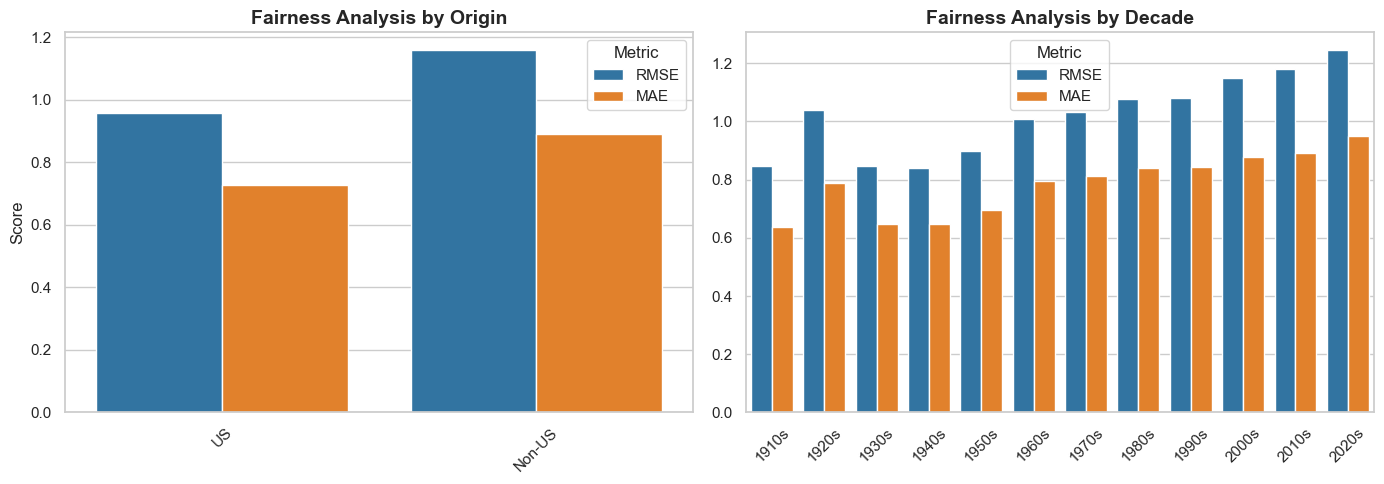

In [8]:
def compute_metrics(df_subset):
    if len(df_subset) == 0:
        return np.nan, np.nan
    rmse = np.sqrt(mean_squared_error(df_subset['averageRating'], df_subset['Predicted_Rating']))
    mae = mean_absolute_error(df_subset['averageRating'], df_subset['Predicted_Rating'])
    return rmse, mae

fairness_records = []

us_subset = analysis_df[analysis_df['Country'].fillna('').str.contains('US|USA|United States', regex=True, case=False)]
non_us_subset = analysis_df[~analysis_df['Country'].fillna('').str.contains('US|USA|United States', regex=True, case=False)]

rmse_us, mae_us = compute_metrics(us_subset)
fairness_records.append({'Category': 'Origin', 'Group': 'US', 'Count': len(us_subset), 'RMSE': rmse_us, 'MAE': mae_us})

rmse_non_us, mae_non_us = compute_metrics(non_us_subset)
fairness_records.append({'Category': 'Origin', 'Group': 'Non-US', 'Count': len(non_us_subset), 'RMSE': rmse_non_us, 'MAE': mae_non_us})

analysis_df['decade'] = (analysis_df['startYear'] // 10) * 10
for decade, subset in analysis_df.groupby('decade'):
    if len(subset) > 50:
        rmse, mae = compute_metrics(subset)
        fairness_records.append({'Category': 'Decade', 'Group': f'{int(decade)}s', 'Count': len(subset), 'RMSE': rmse, 'MAE': mae})

fairness_df = pd.DataFrame(fairness_records)

print("--- Fairness Analysis Results ---")
display(fairness_df)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Origin', 'Decade']

for i, cat in enumerate(categories):
    cat_df = fairness_df[fairness_df['Category'] == cat]

    melted_df = cat_df.melt(id_vars=['Group'], value_vars=['RMSE', 'MAE'],
                            var_name='Metric', value_name='Error Score')

    sns.barplot(data=melted_df, x='Group', y='Error Score', hue='Metric', ax=axes[i], palette=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'Fairness Analysis by {cat}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score' if i==0 else '')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Feature Importance Analysis

In [9]:
best_elastic = grid_elastic.best_estimator_
best_rf = grid_rf.best_estimator_

en_feature_names = best_elastic.named_steps['preprocessor'].get_feature_names_out()
en_coefs = best_elastic.named_steps['model'].coef_

en_importance = pd.DataFrame({
    'Feature': en_feature_names,
    'Coefficient': en_coefs
})

en_importance['Abs_Coefficient'] = en_importance['Coefficient'].abs()
top5_en = en_importance.sort_values(by='Abs_Coefficient', ascending=False).head(5).copy()

top5_en['Direction'] = np.where(top5_en['Coefficient'] > 0, 'Positive (+)', 'Negative (-)')

print("🎯 --- Top 5 Features: Elastic Net --- 🎯")
display(top5_en[['Feature', 'Coefficient', 'Direction']])


rf_feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
rf_importances = best_rf.named_steps['model'].feature_importances_

tree_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
})

top5_tree = tree_importance_df.sort_values(by='Importance', ascending=False).head(5).copy()

X_processed_rf = pd.DataFrame(
    best_rf.named_steps['preprocessor'].transform(X_raw),
    columns=rf_feature_names
)

directions_tree = []
y_aligned = y.reset_index(drop=True)

for feat in top5_tree['Feature']:
    corr = X_processed_rf[feat].corr(y_aligned)
    directions_tree.append('Positive (+)' if corr > 0 else 'Negative (-)')

top5_tree['Direction'] = directions_tree

print("\n🌲 --- Top 5 Features: Random Forest --- 🌲")
display(top5_tree[['Feature', 'Importance', 'Direction']])

🎯 --- Top 5 Features: Elastic Net --- 🎯


,Feature,Coefficient,Direction
14,num__genre_Documentary,0.434470,Positive (+)
13,num__genre_Horror,-0.432810,Negative (-)
10,num__genre_Thriller,-0.332079,Negative (-)
12,num__genre_Sci-Fi,-0.291273,Negative (-)
0,num__runtimeMinutes,0.263189,Positive (+)



🌲 --- Top 5 Features: Random Forest --- 🌲


,Feature,Importance,Direction
14,num__genre_Documentary,0.316391,Positive (+)
13,num__genre_Horror,0.224617,Negative (-)
0,num__runtimeMinutes,0.183421,Positive (+)
9,num__genre_Drama,0.096399,Positive (+)
2,num__is_post_imdb,0.047397,Negative (-)
